In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../week1/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

Datu kopa: 12330 rindas, 28 kolonnas


In [2]:
# Izvēlamies iezīmes, kas raksturo klientu sesiju
cluster_features = ['Administrative_Duration', 'Informational_Duration',
                     'ProductRelated_Duration', 'BounceRates', 'ExitRates',
                     'PageValues']

X_cluster = df[cluster_features].copy()
print(f"Klasterizācijai izmantojam {X_cluster.shape[1]} iezīmes:")
print(cluster_features)

Klasterizācijai izmantojam 6 iezīmes:
['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Pārvēršam atpakaļ uz DataFrame ērtākai darbībai
X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
print("Pēc normalizācijas:")
print(X_scaled_df.describe().round(2))

Pēc normalizācijas:
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                      0.00                    0.00   
std                       1.00                    1.00   
min                      -0.46                   -0.24   
25%                      -0.46                   -0.24   
50%                      -0.41                   -0.24   
75%                       0.07                   -0.24   
max                      18.77                   17.87   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00     12330.00   12330.00    12330.00  
mean                     -0.00        -0.00       0.00        0.00  
std                       1.00         1.00       1.00        1.00  
min                      -0.62        -0.46      -0.89       -0.32  
25%                      -0.53        -0.46      -0.59       -0.32  
50%                      -0.31        -0.39

## **Kāpēc normalizācija ir svarīga klasterizācijai?**

K-Means algoritms aprēķina **Eiklīda attālumus** starp punktiem, lai noteiktu, kurš klasteris katram punktam ir vistuvākais. Tas nozīmē, ka iezīmes ar lielākām vērtībām automātiski dominē attāluma aprēķinā.

**Bez normalizācijas** — Algoritms ignorētu atteikumu rādītāju, pat ja tas ir svarīgs klientu uzvedības raksturotājs.

**`StandardScaler` pārveido** katru iezīmi tā, lai:
- vidējā vērtība (mean) = 0
- standartnovirze (std) = 1

Pēc normalizācijas visas iezīmes ir vienādā mērogā un ietekmē klasterizāciju proporcionāli.

***Secinājums:*** Bez normalizācijas klasterus noteiktu galvenokārt sesijas ilgums sekundēs, nevis klientu reālā uzvedības atšķirība.

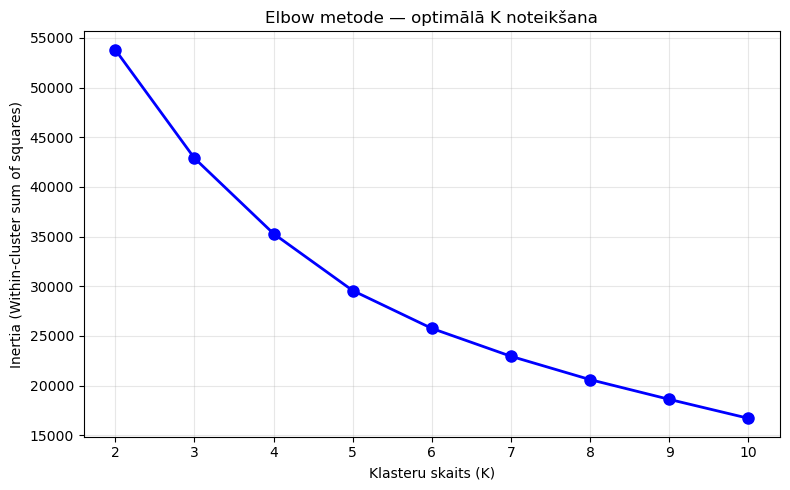

In [4]:
# 2.1. Elbow metode

from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Klasteru skaits (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow metode — optimālā K noteikšana')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**2.2. K vērtības izvēle — Elbow metode**
1. `K_range` norāda klasteru skaitus, kurus pārbaudām — no 2 līdz 10. Sākam ar 2, jo 1 klasteris nozīmētu, ka visi klienti ir vienā grupā. Beidzam ar 10, jo lielāks skaits kļūst grūti interpretējams.
2. Es izvēlos **K = 4**, jo tur inertias kritums pirmo reizi būtiski palēninās. No K=4 uz K=5 kritums ir ~5500, bet no K=2 uz K=3 — ~11000. Tas nozīmē, ka ceturtais klasteris vēl pievieno vērtību, bet piektais — jau krietni mazāk.
3. Grafikā inertia krīt strauji no K=2 (54000) līdz K=4 (35000). Sākot ar K=5, krituma temps ievērojami palēninās un līkne kļūst gandrīz lineāra. Šī lūzuma zona starp K=4 un K=5 ir "elkoņa" punkts.

*Piezīme:*
Nav vienas "pareizas" atbildes — Elbow metode ir interpretācija. Šajos datos "elkoņa" punkts nav pilnīgi ass, tāpēc K=5 arī būtu pamatota izvēle. Galvenais kritērijs ir spēja skaidri interpretēt katru klasteru grupu.

In [5]:
#3.1. Uztrenē galīgo K-Means modeli
# Izmanto izvēlēto K vērtību (piemēram, 4)
K = 6  # <-- nomainiet uz savu izvēlēto vērtību

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"Klasteru sadalījums:")
print(df['Cluster'].value_counts().sort_index())

Klasteru sadalījums:
Cluster
0    9264
1     926
2     958
3     644
4     359
5     179
Name: count, dtype: int64


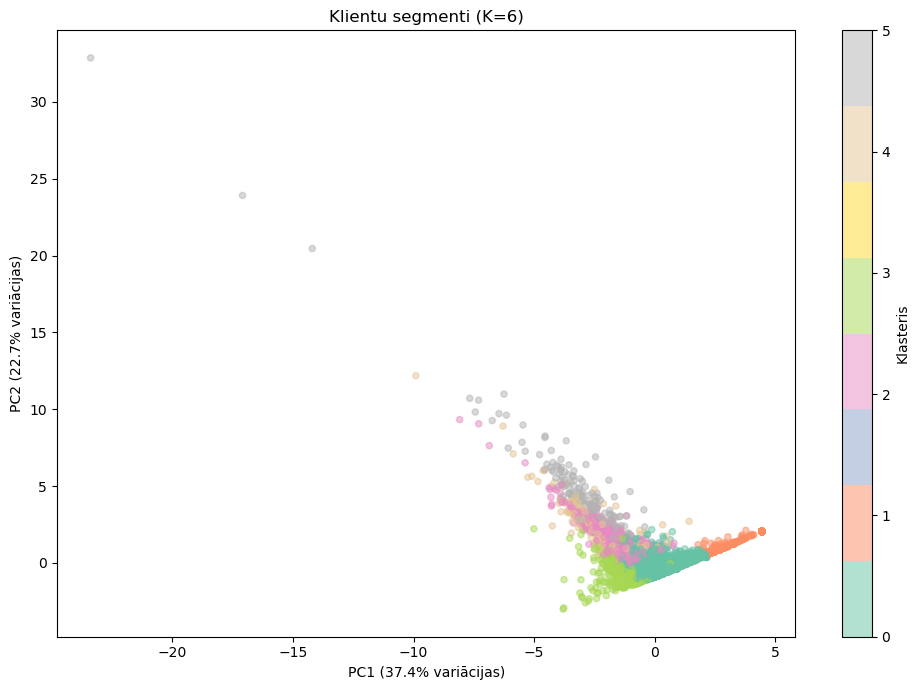

In [6]:
#3.2. Vizualizē klasterus ar PCA
from sklearn.decomposition import PCA

# Samazinām dimensijas līdz 2 vizualizācijai
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=df['Cluster'], cmap='Set2', alpha=0.5, s=20)
plt.colorbar(scatter, label='Klasteris')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variācijas)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variācijas)')
plt.title(f'Klientu segmenti (K={K})')
plt.tight_layout()
plt.show()

Klasteru profili (vidējās vērtības):
         Administrative_Duration  Informational_Duration  \
Cluster                                                    
0                          -0.17                   -0.14   
1                          -0.45                   -0.24   
2                           0.37                    0.33   
3                           0.02                   -0.07   
4                           4.03                    0.24   
5                           1.00                    6.67   

         ProductRelated_Duration  BounceRates  ExitRates  PageValues  
Cluster                                                               
0                          -0.22        -0.25      -0.18       -0.20  
1                          -0.60         3.25       2.97       -0.32  
2                           2.17        -0.32      -0.46       -0.07  
3                          -0.00        -0.40      -0.59        3.35  
4                           0.49        -0.30      -0.44

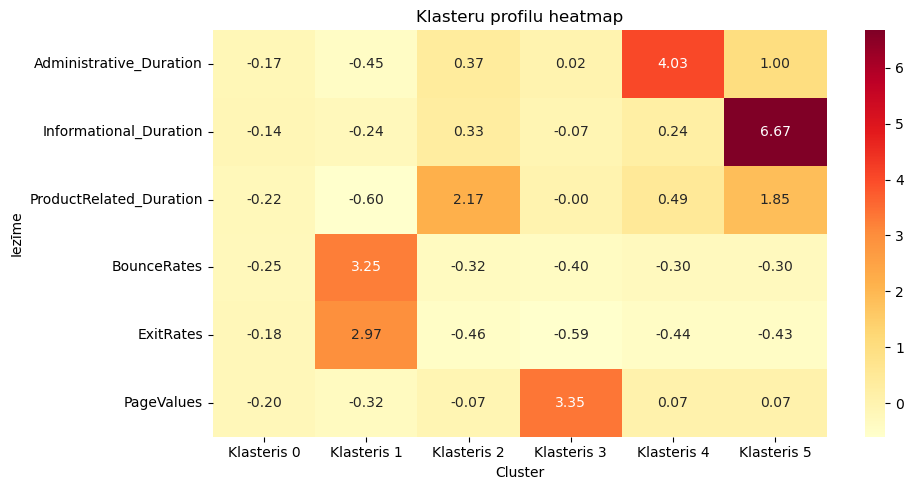

In [7]:
#3.3. Klasteru profili un heatmap
# Katra klastera vidējās vērtības (pirms normalizācijas — lai būtu interpretējami)
X_cluster_with_labels = df[cluster_features + ['Cluster']].copy()

cluster_profiles = X_cluster_with_labels.groupby('Cluster').mean().round(2)
print("Klasteru profili (vidējās vērtības):")
print(cluster_profiles)

# Vizuāli — heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'Klasteris {i}' for i in range(K)])
plt.title('Klasteru profilu heatmap')
plt.ylabel('Iezīme')
plt.tight_layout()
plt.show()

Pirkumu īpatsvars pa klasteriem:
Cluster
0    0.107
1    0.005
2    0.289
3    0.786
4    0.226
5    0.279
Name: Revenue, dtype: float64


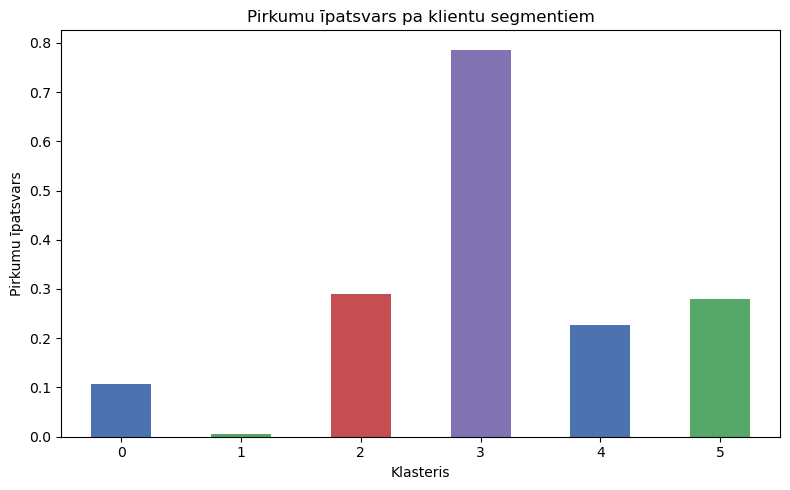

In [8]:
#4.1. Klasteru raksturojums ar pirkumiem
# Cik procentu katra klastera klientu veica pirkumu?
purchase_by_cluster = df.groupby('Cluster')['Revenue'].mean().round(3)
print("Pirkumu īpatsvars pa klasteriem:")
print(purchase_by_cluster)

plt.figure(figsize=(8, 5))
purchase_by_cluster.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Pirkumu īpatsvars pa klientu segmentiem')
plt.xlabel('Klasteris')
plt.ylabel('Pirkumu īpatsvars')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Klientu segmentu biznesa interpretācija**

Balstoties uz klasterizācijas rezultātiem, klienti tika sadalīti 6 segmentos ar atšķirīgu pirkumu uzvedību (potenciālu):

**Klasteris 3 — “Aktīvie pircēji”**  
Šai grupai ir visaugstākais pirkumu īpatsvars (~78.6%), kas nozīmē, ka šie klienti ļoti bieži veic pirkumus. Tie, visticamāk, ir lojāli un mērķtiecīgi klienti ar augstu interesi par produktiem. Šai grupai būtu lietderīgi piedāvāt lojalitātes programmas vai personalizētus ieteikumus.

**Klasteris 2 — “Potenciālie pircēji”**  
Šī segmenta klientiem pirkumu īpatsvars ir salīdzinoši augsts (~28.9%). Viņi izrāda interesi par produktiem, bet ne vienmēr pabeidz pirkumu procesu. Šai grupai varētu palīdzēt īpaši atlaižu kuponi.

**Klasteris 5 — “Neregulārie pircēji”**  
Klastera klienti veic pirkumus vidēji bieži (~27.9%). Tie var būt klienti, kuri iepērkas tikai noteiktās situācijās vai akciju laikā. Šai grupai būtu efektīvi piedāvāt sezonālas akcijas un e-pasta kampaņas ar populārākajiem produktiem.

*Manā gadījumā:* Klasteri 2 un 5 ir salīdzinoši līdzīgi pēc pirkumu īpatsvara, jo abos segmentos aptuveni 28% klientu veica pirkumu. Tas var norādīt, ka šo grupu klientiem ir līdzīga iepirkšanās aktivitāte, taču klasterizācijas algoritms tos atdalīja pēc citām pazīmēm, piemēram, lapu skatījumiem vai sesijas ilguma.

**Klasteris 4 — “Interesi izrādošie apmeklētāji”**  
Šie klienti pirkumus veic retāk (~22.6%), tomēr viņi izrāda zināmu aktivitāti vietnē. Tas var nozīmēt, ka viņi salīdzina produktus vai vēl nav pilnībā pārliecināti par pirkumu. Uzņēmums varētu izmantot produktu rekomendācijas un sociālo tīklu atsaukmes vai vērtējumus, lai palielinātu uzticību.

**Klasteris 0 — “Pasīvie apmeklētāji”**  
Šajā segmentā pirkumu īpatsvars ir zems (~10.7%). Šie lietotāji, iespējams, tikai pārlūko vietni bez konkrēta mērķa iegādāties produktus. Viņus varētu motivēt ar pirmā pirkuma atlaidēm, skaistu vizualizāciju vai vienkāršotu pirkuma procesu.

**Klasteris 1 — “Ātrie aizgājēji”**  
Šim klasterim ir viszemākais pirkumu īpatsvars (~0.5%), kas norāda, ka klienti gandrīz neveic pirkumus. Iespējams, viņi vietni pamet ļoti ātri vai neatrod sev interesējošu saturu. Šai grupai uzņēmumam vajadzētu analizēt lietotāju pieredzi, uzlabot sākumlapu un izmantot reklāmas atkārtotai klientu piesaistei.

In [9]:
#5.1. Ielādē datus un modeļi
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Ielādē datus (tu tos jau ielādēji, tāpēc varētu būt kļūda)
y = df['Revenue']
X = df.drop(['Revenue', 'Cluster'], axis=1)  # Izņem mūsu klasteru kolonu

print(f"Datu kopa: {X.shape[0]} rindas, {X.shape[1]} features")

Datu kopa: 12330 rindas, 27 features


In [10]:
#5.2. Viena train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
single_f1 = f1_score(y_test, rf.predict(X_test))

print(f"Viena split F1 score: {single_f1:.3f}")

Viena split F1 score: 0.635


In [11]:
#5.3. Cross-validation (5-fold)
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

cv_scores = cross_val_score(
    rf_cv, X, y,
    cv=5,
    scoring='f1'
)

print(f"5-fold CV F1 scores: {cv_scores.round(3)}")
print(f"Vidējais F1: {cv_scores.mean():.3f}")
print(f"Standarta novirze: {cv_scores.std():.3f}")

5-fold CV F1 scores: [0.668 0.661 0.652 0.551 0.612]
Vidējais F1: 0.629
Standarta novirze: 0.043


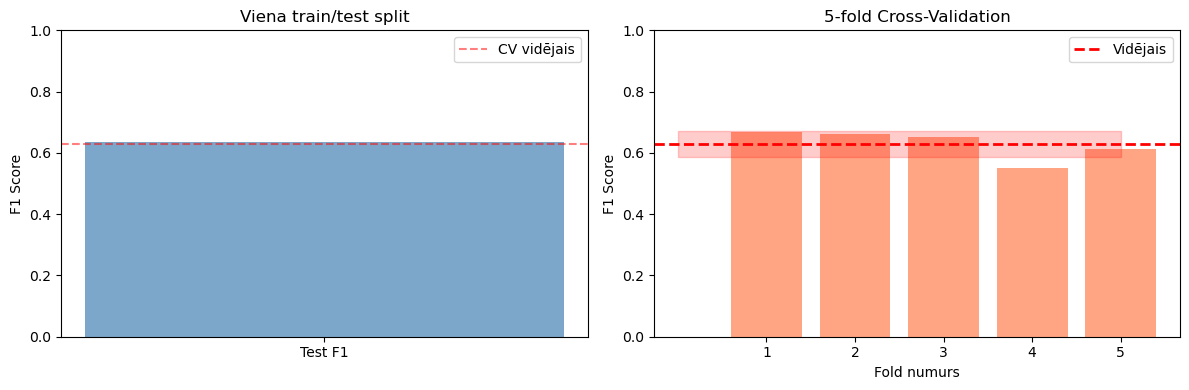

In [12]:
#5.4. Vizualizācija
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Viena split
axes[0].bar(['Test F1'], [single_f1], color='steelblue', alpha=0.7)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Viena train/test split')
axes[0].set_ylim([0, 1])
axes[0].axhline(y=cv_scores.mean(), color='red', linestyle='--', alpha=0.5, label='CV vidējais')
axes[0].legend()

# Cross-validation
axes[1].bar(range(1, 6), cv_scores, color='coral', alpha=0.7)
axes[1].axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, label='Vidējais')
axes[1].fill_between(
    range(0, 6),
    cv_scores.mean() - cv_scores.std(),
    cv_scores.mean() + cv_scores.std(),
    alpha=0.2, color='red'
)
axes[1].set_xlabel('Fold numurs')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('5-fold Cross-Validation')
axes[1].set_ylim([0, 1])
axes[1].set_xticks(range(1, 6))
axes[1].legend()

plt.tight_layout()
plt.show()

**5.5. Analīze — Viena split vs. Cross-Validation**

Viena split F1 (0.635) un CV vidējais F1 (0.629) ir ļoti līdzīgi — starpība ir tikai 0.006 jeb mazāk par 1%. Taču tas ir sakritība, nevis likumsakarība — viena split rezultāts ir atkarīgs no tā, kuri dati nejauši nonāca test kopā.

CV rezultāts ir uzticamāks, jo modelis tika novērtēts 5 reizes uz dažādām
datu daļām, nevis vienu reizi. Tas dod pareizāku priekšstatu par to, kā
modelis strādās ar jauniem, neredzētiem datiem.

Standarta novirze 0.043 parāda, ka fold rezultāti svārstās — no ~ 0.551 (fold 4) līdz ~ 0.668 (fold 1). Fold nr.4 ir ievērojami zemāks, kas nozīmē, ka šajā datu daļā bija grūtāki vai atšķirīgāki piemēri. Tā ir reāla informācija par modeļa nestabilitāti.

Ja palaistu viena split kodu ar citu random_state, F1 varētu sanākt 0.551
vai 0.668 — jebkurš skaitlis CV diapazonā. Tāpēc viena split F1 vien nedrīkst izmantot, lai spriestu par modeļa kvalitāti.

In [13]:
# 6.1. Bīstama versija: data leakage
from sklearn.preprocessing import StandardScaler

# ✗ NEPAREIZI - data leakage!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # ← Fit uz VISIEM datiem!

X_train_leaked, X_test_leaked, y_train_l, y_test_l = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

rf_leaked = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_leaked.fit(X_train_leaked, y_train_l)
f1_leaked = f1_score(y_test_l, rf_leaked.predict(X_test_leaked))

print(f"F1 ar data leakage: {f1_leaked:.3f}")

F1 ar data leakage: 0.635


In [14]:
# 6.2. Pareizā versija: Pipeline
from sklearn.pipeline import make_pipeline

# ✓ PAREIZI - Pipeline
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
)

# Trenēšana ar cross-validation
cv_scores_pipe = cross_val_score(
    pipe, X, y,
    cv=5,
    scoring='f1'
)

print(f"F1 ar Pipeline: {cv_scores_pipe.mean():.3f} ± {cv_scores_pipe.std():.3f}")

F1 ar Pipeline: 0.629 ± 0.045


In [15]:
# 6.3. Salīdzinājums
comparison = pd.DataFrame({
    'Metode': ['Data leakage (viena split)', 'Pipeline + Cross-validation'],
    'F1 Score': [f1_leaked, cv_scores_pipe.mean()],
    'Ticamība': ['BĪSTAMS! Neobjektīvs', 'DROŠS! Objektīvs']
})

print(comparison.to_string(index=False))

                     Metode  F1 Score             Ticamība
 Data leakage (viena split)  0.635258 BĪSTAMS! Neobjektīvs
Pipeline + Cross-validation  0.628553     DROŠS! Objektīvs


**SKAIDROJUMS - Data leakage un Pipeline**

Data leakage jeb "datu noplūde" notiek, kad modelis mācīšanās procesā nejauši "iegūst informāciju" no test datiem, kurus tam vajadzētu redzēt tikai pārbaudē. Rezultāts izskatās labāks nekā modelis patiesībā ir.

Ja `StandardScaler` tiek `fit` pirms train/test split, tas aprēķina vidējo vērtību un standartnovirzi no *visiem* datiem — arī no test kopas. Tādējādi test dati netieši ietekmē pareizību un modelis tos "pazīst" jau pirms pārbaudes.

`Pipeline` novērš šo problēmu automātiski: katrā CV fold solī skalers tiek `fit` tikai uz train daļu, bet test daļai tiek piemērots tikai `transform`. Test dati nekad neietekmē normalizācijas parametrus.

Gala projektā tas ir kritiski — ja modelis tiek novērtēts ar data leakage, tu ziņosi F1 = 0.635, bet reālajā lietošanā modelis strādās sliktāk (0.629 vai zemāk). Tas var novest pie kļūdainiem biznesa lēmumiem, kas balstīti uz pārāk optimistiskiem rezultātiem. Tāpēc `Pipeline + Cross-Validation` ir obligāts nosacījums godīgai modeļa novērtēšanai.

In [16]:
# 7.1. Parametru tīkls un meklēšana
from sklearn.model_selection import GridSearchCV

# Pipeline, kam meklēsim parametrus
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

# Parametru tīkls — 2 parametri, 3×3 kombinācijas = 9 mēģinājumi
param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, 20]
}

# GridSearchCV: cross-validation + automātiska meklēšana
grid = GridSearchCV(
    pipe, param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,  # Izmanto visas CPU kodolus
    verbose=1
)

# Trenēšana (tikai uz training datiem!)
X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

grid.fit(X_train_gs, y_train_gs)

print(f"Labākie parametri: {grid.best_params_}")
print(f"Labākais CV F1 (treniņā): {grid.best_score_:.3f}")
print(f"Test F1 (ar labākajiem parametriem): {f1_score(y_test_gs, grid.predict(X_test_gs)):.3f}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Labākie parametri: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 200}
Labākais CV F1 (treniņā): 0.653
Test F1 (ar labākajiem parametriem): 0.629


In [17]:
#7.2. Detalizēta rezultātu analīze
# Kādi bija VISIEM parametriem?
results_df = pd.DataFrame(grid.cv_results_)
results_table = results_df[[
    'param_randomforestclassifier__n_estimators',
    'param_randomforestclassifier__max_depth',
    'mean_test_score',
    'std_test_score'
]].sort_values('mean_test_score', ascending=False)

print("Top 5 parametru kombinācijas:")
print(results_table.head())

Top 5 parametru kombinācijas:
   param_randomforestclassifier__n_estimators  \
8                                         200   
7                                         100   
5                                         200   
4                                         100   
6                                          50   

   param_randomforestclassifier__max_depth  mean_test_score  std_test_score  
8                                       20         0.653164        0.012239  
7                                       20         0.649086        0.017458  
5                                       10         0.647174        0.011353  
4                                       10         0.645475        0.008885  
6                                       20         0.643574        0.013674  


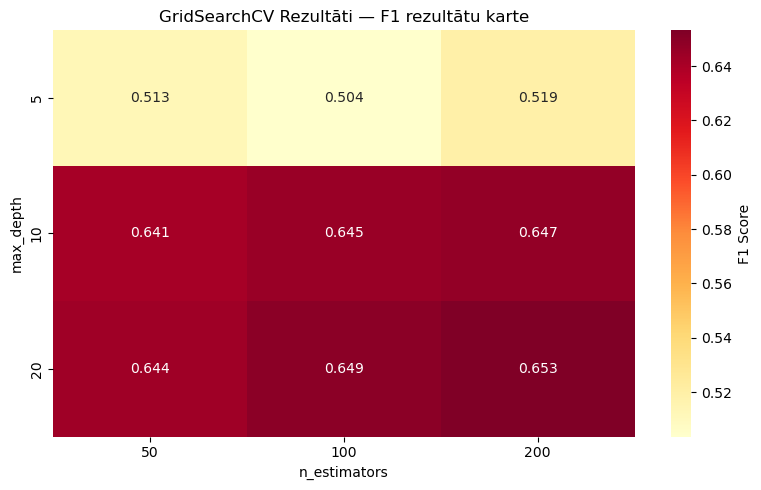

In [18]:
#7.3. Vizualizācija: heatmap
# Pivot tabula — n_estimators kolonnas, max_depth rindas
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_randomforestclassifier__max_depth',
    columns='param_randomforestclassifier__n_estimators'
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    cbar_kws={'label': 'F1 Score'}
)
plt.title('GridSearchCV Rezultāti — F1 rezultātu karte')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()

**GridSearchCV INTERPRETĀCIJA**

Labākie parametri bija `max_depth=20` un `n_estimators=200`, kas deva CV F1 = 0.653 ar standartnovirzi tikai 0.012 — stabils un uzticams rezultāts. 

Starpība starp labāko kombināciju (F1 = 0.653) un sliktāko no visām 9 kombinācijām (`max_depth=5`, F1 ≈ 0.504–0.519, redzams heatmapā) ir aptuveni 0.149 — tas ir ļoti liels uzlabojums, ko dod pareiza parametru izvēle. 

Heatmapā skaidri redzamas divas zonas: `max_depth=10` un `max_depth=20` rindas ir tumši sarkanas (F1 0.641–0.653), bet `max_depth=5` rinda ir dzeltena (F1 ~0.51). Tas pierāda, ka `max_depth` ir izšķirošais parametrs, bet `n_estimators` ietekmē rezultātu daudz mazāk. 

GridSearchCV atrada labākus parametrus nekā manuāli izvēlētie. Manuālais modelis deva F1 = 0.629, bet GridSearchCV labākā kombinācija (`max_depth=20, n_estimators=200`) deva F1 = 0.653 — uzlabojums par 0.024. Manuāli grūti pārbaudīt visas kombinācijas, bet GridSearchCV sistemātiski izmēģināja visas 9 kombinācijas un atrada optimālo.

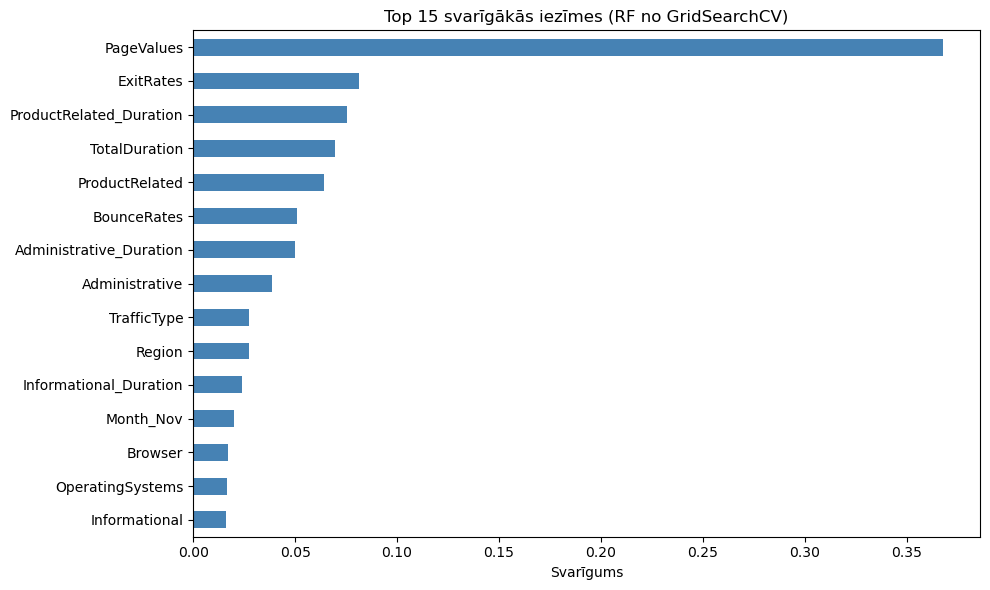

Top 10 svarīgākās iezīmes:
PageValues                 0.367569
ExitRates                  0.081168
ProductRelated_Duration    0.075586
TotalDuration              0.069522
ProductRelated             0.063952
BounceRates                0.050973
Administrative_Duration    0.049905
Administrative             0.038452
TrafficType                0.027520
Region                     0.027481
dtype: float64


In [19]:
# 8.1. Feature importance no labākā modeļa
# Iegūt labāko trenēto modeli
best_model = grid.best_estimator_

# RandomForestClassifier nodrošina feature_importances_
rf_inside = best_model.named_steps['randomforestclassifier']
importances = rf_inside.feature_importances_

# Sakārtot un vizualizēt
feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importance.tail(15).plot(kind='barh', color='steelblue')
plt.xlabel('Svarīgums')
plt.title('Top 15 svarīgākās iezīmes (RF no GridSearchCV)')
plt.tight_layout()
plt.show()

# Arī teksts
print("Top 10 svarīgākās iezīmes:")
print(feature_importance.sort_values(ascending=False).head(10))

**Feature Importance interpretācija**

Trīs svarīgākās iezīmes ir `PageValues` (0.368), `ExitRates` (0.081) un `ProductRelated_Duration` (0.076).

`PageValues` ir dominējošā iezīme ar lielu pārsvaru — tā veidо 37% no modeļa lēmumiem. Tā atspoguļo, cik "vērtīgas" bija apmeklētās lapas ceļā uz pirkumu — klients, kurš skatīja produktu lapas un checkout procesu, automātiski iegūst augstāku `PageValues` vērtību.
`ExitRates` parāda, vai klients pameta vietni bez pirkuma — augsts rādītājs ir spēcīgs signāls, ka pirkums nenotiks. 
`ProductRelated_Duration` mēra, cik ilgi klients pavadīja laiku produktu lapās — ilgāka uzturēšanās norāda uz lielāku interesi un pirkuma nodomu.

Mārketinga departaments varētu izmantot šo informāciju trīs veidos: 
1)	 koncentrēt retargeting reklāmas uz klientiem ar augstu `PageValues` bet bez pirkuma — viņi bija gandrīz gatavi pirkt; 
2)	analizēt lapas ar augstu `ExitRates` un uzlabot tās (labāki attēli, cenas, plašāka informācija), lai samazinātu klientu aizplūšanu; 
3)	klientiem, kuri ilgi uzturas produktu lapās bet nepērk, automātiski piedāvāt atlaidi vai bezmaksas piegādi — tas var izšķirt pirkuma lēmumu.

In [20]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [21]:
# 9.1. Abi modeļi ar cross-validation
from xgboost import XGBClassifier

# RandomForest (ar labākajiem parametriem no GridSearchCV)
rf_final = RandomForestClassifier(
    n_estimators=grid.best_params_['randomforestclassifier__n_estimators'],
    max_depth=grid.best_params_['randomforestclassifier__max_depth'],
    random_state=42
)

pipe_rf = make_pipeline(StandardScaler(), rf_final)
cv_rf = cross_val_score(pipe_rf, X, y, cv=5, scoring='f1')

# XGBoost (standarta parametri, vienkāršības dēļ)
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42,
    eval_metric='logloss'
)

pipe_xgb = make_pipeline(StandardScaler(), xgb)
cv_xgb = cross_val_score(pipe_xgb, X, y, cv=5, scoring='f1')

# Salīdzinājums
print(f"RandomForest CV F1: {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")
print(f"XGBoost CV F1:      {cv_xgb.mean():.3f} ± {cv_xgb.std():.3f}")

RandomForest CV F1: 0.635 ± 0.043
XGBoost CV F1:      0.614 ± 0.056


In [22]:
# 9.2. Detalizēta tabula
comparison_table = pd.DataFrame({
    'Modelis': ['RandomForest', 'XGBoost'],
    'CV vidējais F1': [cv_rf.mean(), cv_xgb.mean()],
    'Std dev': [cv_rf.std(), cv_xgb.std()],
    'Diapazons': [f"{cv_rf.min():.3f}-{cv_rf.max():.3f}",
                  f"{cv_xgb.min():.3f}-{cv_xgb.max():.3f}"]
})

print(comparison_table.to_string(index=False))

     Modelis  CV vidējais F1  Std dev   Diapazons
RandomForest        0.634523 0.042623 0.572-0.689
     XGBoost        0.613835 0.056357 0.538-0.697


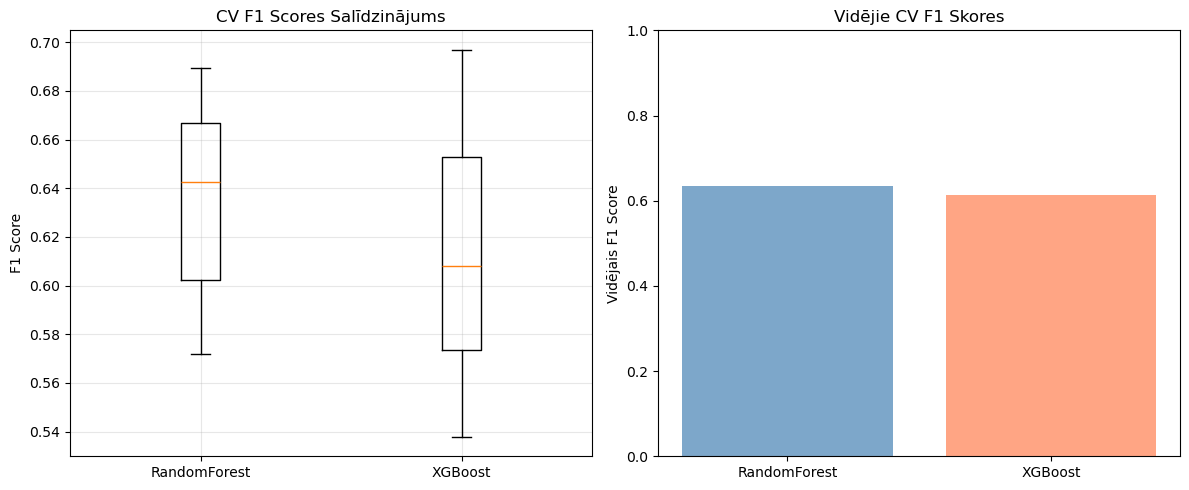

In [23]:
# 9.3. Vizualizācija
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
models_scores = [cv_rf, cv_xgb]
axes[0].boxplot(models_scores, tick_labels=['RandomForest', 'XGBoost'])
axes[0].set_ylabel('F1 Score')
axes[0].set_title('CV F1 Scores Salīdzinājums')
axes[0].grid(True, alpha=0.3)

# Bar plot ar vidējiem
axes[1].bar(['RandomForest', 'XGBoost'], [cv_rf.mean(), cv_xgb.mean()], alpha=0.7, color=['steelblue', 'coral'])
axes[1].set_ylabel('Vidējais F1 Score')
axes[1].set_title('Vidējie CV F1 Skores')
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

**SECINĀJUMI — RandomForest vs. XGBoost** 

RandomForest uzrāda labāku rezultātu ar CV F1 = 0.635, salīdzinot ar XGBoost CV F1 = 0.614. Tāpēc gala projektam es izvēlos RandomForest modeli, jo tas strādā nedaudz labāk un daudz stabilāk nekā XGBoost.

Atšķirība nav statistiski dramatiska, taču RandomForest ir ievērojami stabilāks — standartnovirze 0.043 pret XGBoost 0.056. RandomForest diapazons ir 0.572–0.689, bet XGBoost 0.538–0.697, kas nozīmē, ka XGBoost dažos fold strādā sliktāk un ir mazāk paredzams. 

Gala projektam izvēlētos **RandomForest** trīs iemeslu dēļ: 
1)	 tas nodrošina augstāku un drošāk prognozējamu precizitāti bez pēkšņiem kļūdu kritumiem;
2)	mazāka standartnovirze nozīmē, ka modelis uzvedas konsekventāki uz dažādiem datiem; 
3)	sniedz labu rezultātu uzreiz ar noklusējuma iestatījumiem, kas ļauj ietaupīt laiku un datora resursus, kurus XGBoost prasītu sarežģītai parametru piemeklēšanai.